In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from KWD import compareOneToOne, compareOneToMany, compareAll, focusArea
from sklearn.manifold import (
    MDS,
    TSNE,
    Isomap,
    LocallyLinearEmbedding,
    SpectralEmbedding,
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering

In [ ]:
crops = gpd.read_file('rpg2020_10000_2154_1.geojson')

In [ ]:
crops['x'] = (crops.geometry.centroid.x - 5000) / 10000
crops['y'] = (crops.geometry.centroid.y - 5000) / 10000
crops.x = crops.x.astype(int)
crops.y = crops.y.astype(int)

In [24]:
culture = ['Autres cultures industrielles', 'Autres céréales', 'Autres oléagineux',
       'Blé tendre', 'Colza', 'Divers', 'Estives et landes', 'Fourrage',
       'Fruits à coque', 'Gel (surfaces gelées sans production)',
       'Légumes ou fleurs', 'Légumineuses à grains', 'Maïs grain et ensilage',
       'Oliviers', 'Orge', 'Plantes à fibres', 'Prairies permanentes',
       'Prairies temporaires', 'Protéagineux', 'Riz', 'Tournesol', 'Vergers',
       'Vignes']
     

I perform the KWD distance between pairs of crops

In [ ]:
Options = { 'L':20}

distance = np.zeros((len(culture), len(culture)))

for i, cul1 in enumerate(culture):
    for j, cul2 in enumerate(culture):
        if i > j:
            sol = compareOneToOne(crops[['x', 'y']].values, crops[[cul1, cul2]].values / crops[[cul1, cul2]].values.sum(axis=0) , Options) 
            distance[i,j] = sol['distance']

In [146]:
distance2 = distance + distance.T

In [147]:
np.save("distance_between_crop.npy", distance2)

### MDS and hclust

In [3]:
distance2 = np.load('distance_between_crop.npy')

First I perform a hclust on a large MDS :

In [ ]:
X_20d = MDS(n_components=20, dissimilarity="precomputed", n_init=2000, n_jobs=6, metric=True).fit_transform(distance2)

In [153]:
# setting distance_threshold=0 ensures we compute the full tree.
clust = AgglomerativeClustering( n_clusters=7).fit(X_20d)
cluster = pd.DataFrame({'culture':culture , 'label':clust.labels_})

Now I perform MDS to plot on 2d plan the crops.

In [ ]:
X_2d = MDS(n_components=2, dissimilarity="precomputed", n_init=2000, n_jobs=6, metric=True, random_state=2610 ).fit_transform(distance2)

In [154]:
df = pd.DataFrame(X_2d*10)
df.columns = df.columns.astype(str)
df = pd.concat([df, cluster], axis=1)

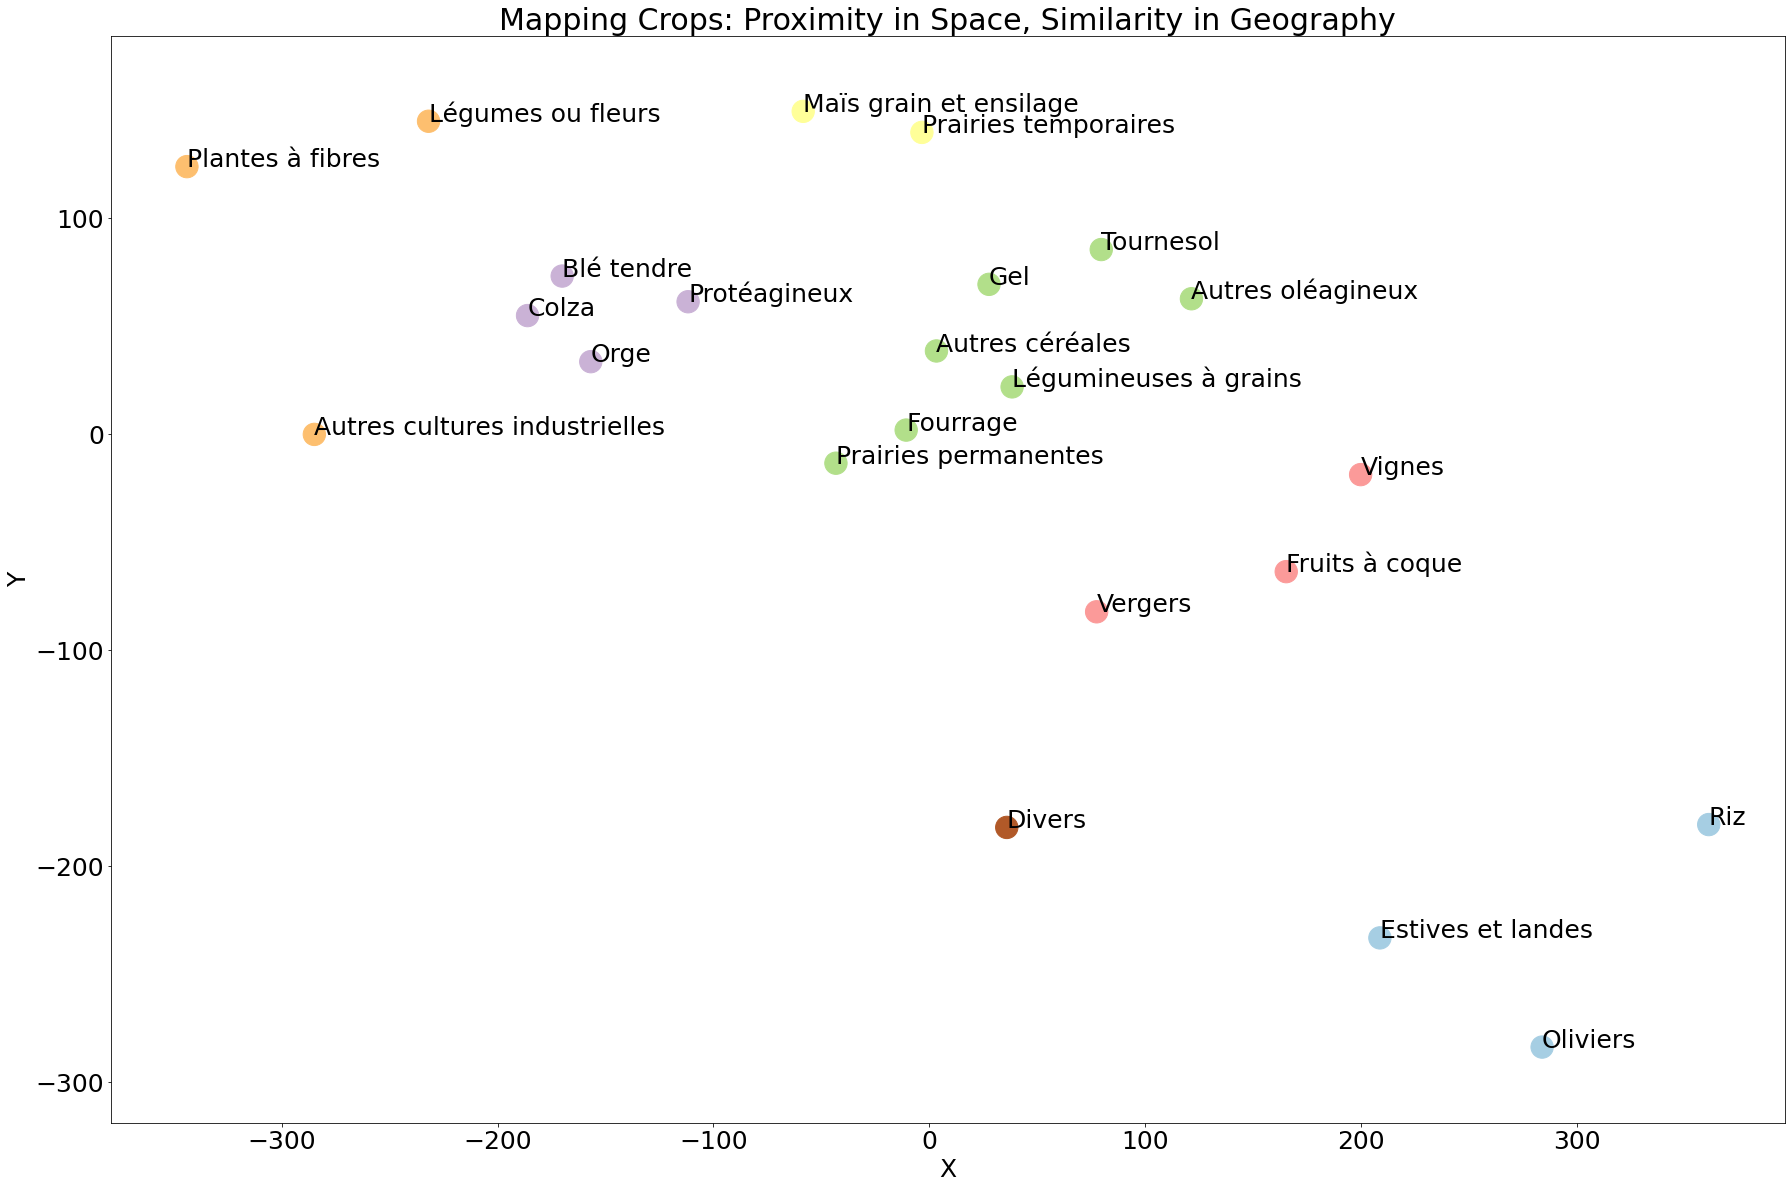

In [157]:
plt.rc('font', size=25)
plt.figure(figsize=(30, 20))
plt.scatter(df['0'], df['1'], c=df['label'], cmap='Paired', s=500)
plt.axis('equal')
plt.title("Mapping Crops: Proximity in Space, Similarity in Geography")
# Set x-axis label
plt.xlabel('X')
# Set y-axis label
plt.ylabel('Y')

for i, label in enumerate(culture):
    if label == 'Gel (surfaces gelées sans production)':
        label = 'Gel'
    x = df.loc[i,'0']
    y = df.loc[i,'1']  
    if label == 'Gel (surfaces gelées sans production)':
        label = 'Gel'
    
    plt.text(x, y , str(label))

In [11]:
X_embedded = TSNE(n_components=2,  perplexity=3, metric='precomputed').fit_transform(distance2 )

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:691: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  warnings.warn(


In [15]:
df = pd.DataFrame(X_embedded)

In [20]:
df.columns = df.columns.astype(str)

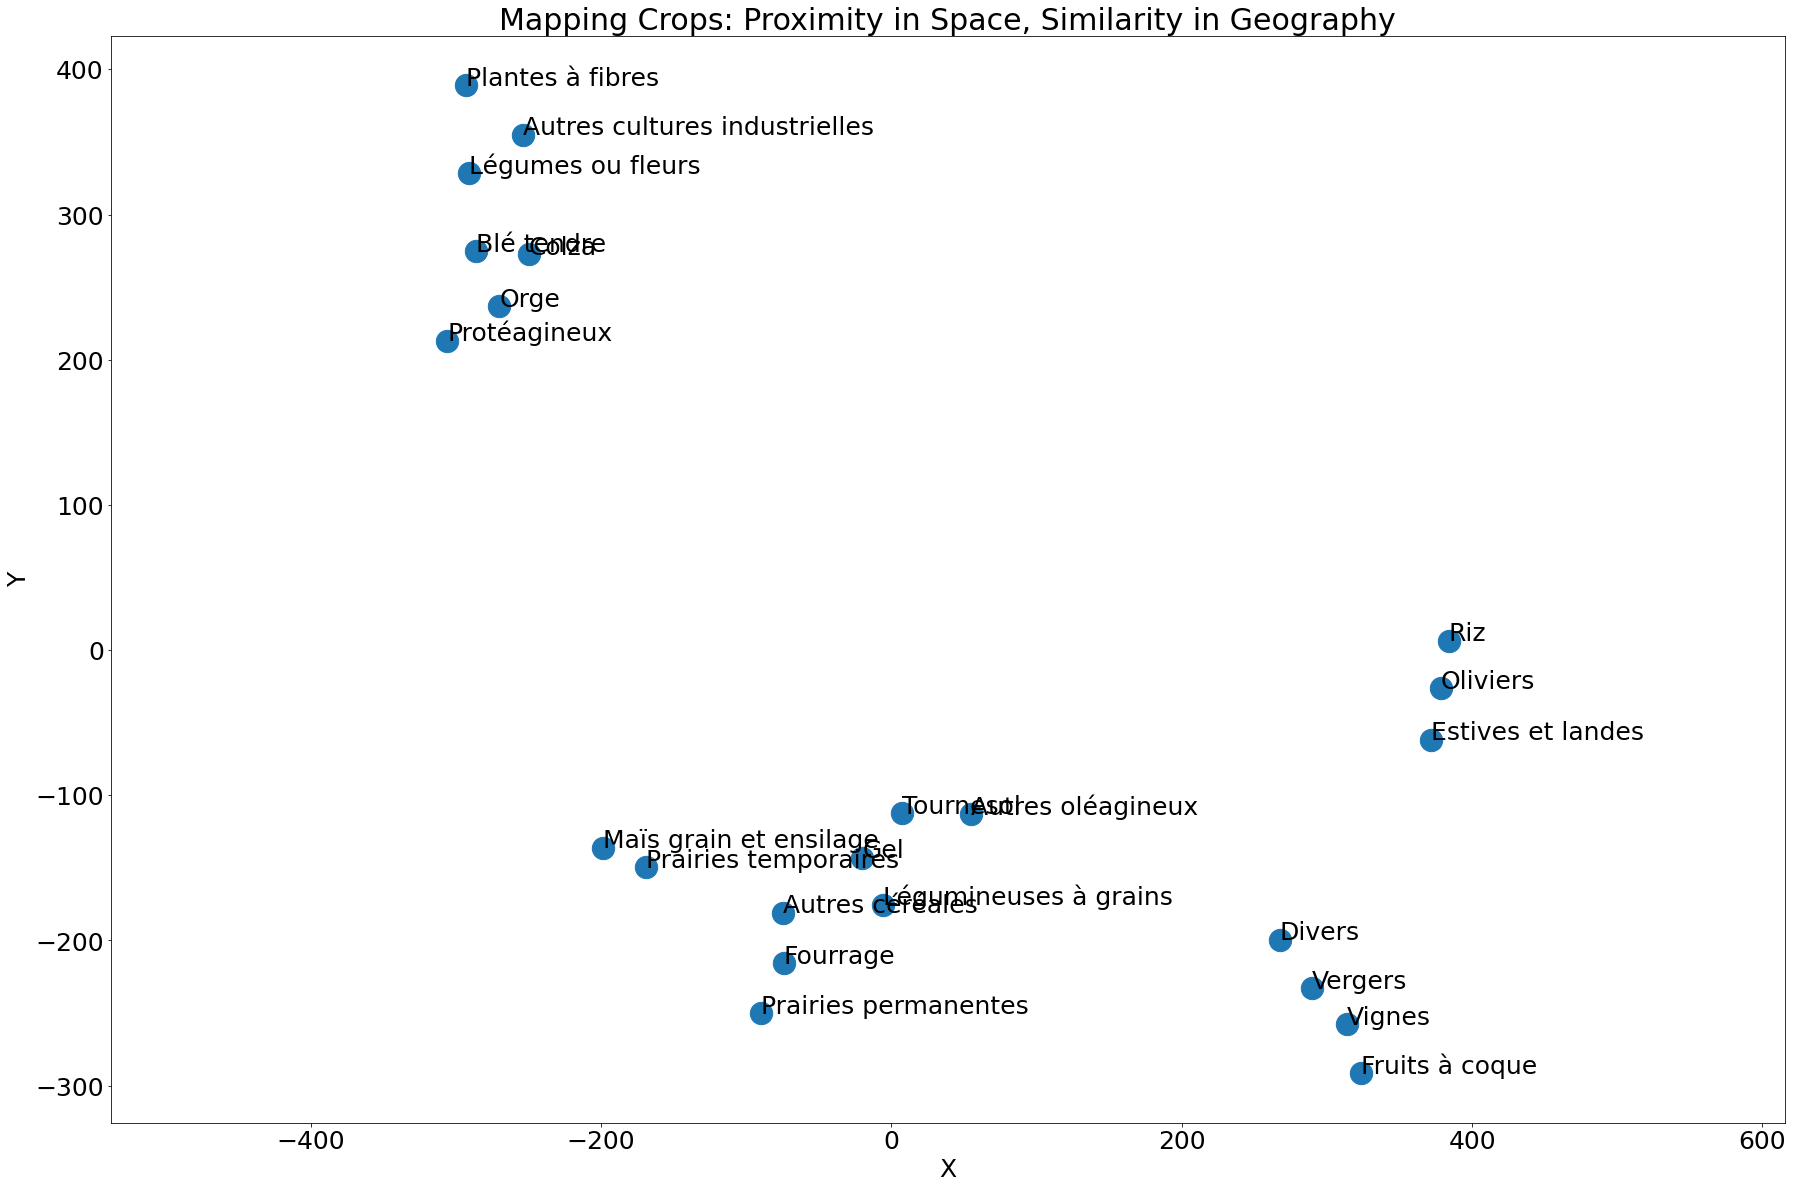

In [25]:
plt.rc('font', size=25)
plt.figure(figsize=(30, 20))
plt.scatter(df['0'], df['1'],  cmap='Paired', s=500)
plt.axis('equal')
plt.title("Mapping Crops: Proximity in Space, Similarity in Geography")
# Set x-axis label
plt.xlabel('X')
# Set y-axis label
plt.ylabel('Y')

for i, label in enumerate(culture):
    if label == 'Gel (surfaces gelées sans production)':
        label = 'Gel'
    x = df.loc[i,'0']
    y = df.loc[i,'1']  
    if label == 'Gel (surfaces gelées sans production)':
        label = 'Gel'
    
    plt.text(x, y , str(label))
